In [384]:
import numpy as np
import scipy
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import colorsys
from matplotlib import ticker
from matplotlib.cbook import file_requires_unicode
#from matplotlib import colormaps
#import math

In [385]:
df = pd.read_csv("hidrogeno2.csv", delimiter=",", skiprows=20)
wavelength = df["nm"].to_numpy()
intensity = df["Value"].to_numpy()

In [386]:
def sample_to_frequency(x):
    return x*(max(wavelength) - min(wavelength))/len(wavelength) + min(wavelength)

sampleSize = (max(wavelength) - min(wavelength)) / len(wavelength)

In [387]:
peakIndex, peakData = scipy.signal.find_peaks(intensity, prominence=0.2)
widths, width_heights, left_ips, right_ips = scipy.signal.peak_widths(intensity, peakIndex, rel_height=0.5)


errors = widths*sampleSize

#print(sample_to_frequency(0))
#print(frequency[left_ips])
#peakError = frequency[peaks[1].get("right_bases")] - frequency[peaks[1].get("left_bases")]

In [388]:
def wavelength_to_rgb(wavelength, gamma=0.8):
    ''' taken from http://www.noah.org/wiki/Wavelength_to_RGB_in_Python
    This converts a given wavelength of light to an
    approximate RGB color value. The wavelength must be given
    in nanometers in the range from 380 nm through 750 nm
    (789 THz through 400 THz).

    Based on code by Dan Bruton
    http://www.physics.sfasu.edu/astro/color/spectra.html
    Additionally alpha value set to 0.5 outside range
    '''
    wavelength = float(wavelength)
    if wavelength >= 380 and wavelength <= 750:
        A = 1.
    else:
        A = 0.5
    if wavelength < 380:
        wavelength = 380.
    if wavelength > 750:
        wavelength = 750.
    if 380 <= wavelength <= 440:
        attenuation = 0.3 + 0.7 * (wavelength - 380) / (440 - 380)
        R = ((-(wavelength - 440) / (440 - 380)) * attenuation) ** gamma
        G = 0.0
        B = (1.0 * attenuation) ** gamma
    elif 440 <= wavelength <= 490:
        R = 0.0
        G = ((wavelength - 440) / (490 - 440)) ** gamma
        B = 1.0
    elif 490 <= wavelength <= 510:
        R = 0.0
        G = 1.0
        B = (-(wavelength - 510) / (510 - 490)) ** gamma
    elif 510 <= wavelength <= 580:
        R = ((wavelength - 510) / (580 - 510)) ** gamma
        G = 1.0
        B = 0.0
    elif 580 <= wavelength <= 645:
        R = 1.0
        G = (-(wavelength - 645) / (645 - 580)) ** gamma
        B = 0.0
    elif 645 <= wavelength <= 750:
        attenuation = 0.3 + 0.7 * (750 - wavelength) / (750 - 645)
        R = (1.0 * attenuation) ** gamma
        G = 0.0
        B = 0.0
    else:
        R = 0.0
        G = 0.0
        B = 0.0
    return (R, G, B, A)


clim = (380, 750)
norm = plt.Normalize(*clim)
wl = np.linspace(clim[0], clim[1], len(wavelength))
colorlist = list(zip(norm(wl), [wavelength_to_rgb(w) for w in wl]))
spectralmap = colors.LinearSegmentedColormap.from_list("spectrum", colorlist)

print(spectralmap(0))

(np.float64(0.3816778909618176), np.float64(0.0), np.float64(0.3816778909618176), np.float64(1.0))


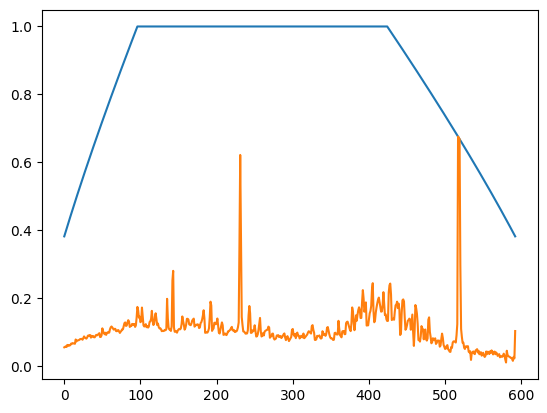

In [389]:
modulatedWavelengthValues = []

maxIntensity = np.max(intensity)
modulatedIntensityValues = np.sqrt((np.abs(intensity/maxIntensity)))
wavelengthInHSV2 = []
wavelengthInHSV2timesMI = []

for w,mI in zip(wl, modulatedIntensityValues):
    wavelengthInRGB = wavelength_to_rgb(w)[0:3]
    wavelengthInHSV = colorsys.rgb_to_hsv(*np.array(wavelengthInRGB))
    wavelengthInHSV2.append(wavelengthInHSV[2])
    wavelengthInHSV2timesMI.append(wavelengthInHSV[2]*mI)
    modulatedWavelength = np.append(wavelengthInHSV[0:2],wavelengthInHSV[2]*mI)#*mI)
    modulatedWavelengthValues.append(colorsys.hsv_to_rgb(*modulatedWavelength))


plt.plot(wavelengthInHSV2)
plt.plot(wavelengthInHSV2timesMI)
#plt.plot(modulatedIntensityValues)

spectralLinesList = list(zip(norm(wl), modulatedWavelengthValues))
spectralLinesMap = colors.LinearSegmentedColormap.from_list("spectralLines", spectralLinesList)


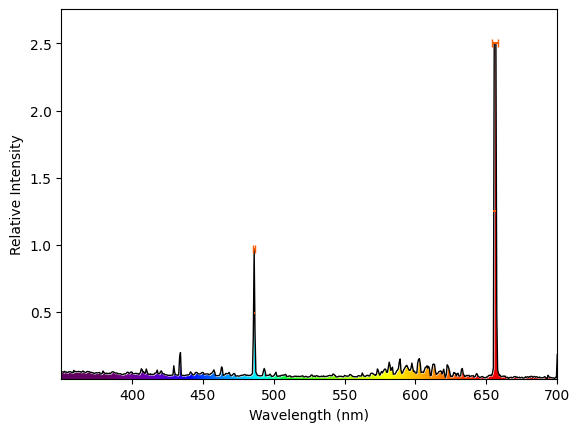

In [390]:
#plt.plot(wavelength, intensity, color ="#BB0000")

X,Y = np.meshgrid(wavelength, intensity)
extent = (np.min(wavelength), np.max(wavelength), np.min(intensity), np.max(intensity))
plt.imshow(X, clim=clim, extent=extent, cmap=spectralmap, aspect='auto')


plt.plot(wavelength, intensity, color = "black", alpha = 1, lw = 1)

plt.errorbar(wavelength[peakIndex], intensity[peakIndex], marker ="", color ="#f75b00", xerr = errors, capsize = 3, linestyle ="None", ecolor ="#f75b00", barsabove=False)#b73b00

plt.xlabel("Wavelength (nm)")
plt.ylabel("Relative Intensity")

plt.hlines(width_heights, sample_to_frequency(left_ips), sample_to_frequency(right_ips), color = "#f75b00")


plt.fill_between(wavelength, intensity, max(intensity*1.05), color='w')



plt.savefig("plotNeonSpectrum.png", dpi = 300)

plt.show()

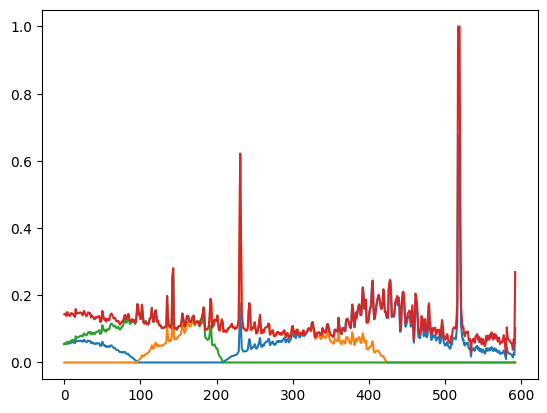

In [391]:
plt.plot(modulatedWavelengthValues)
plt.plot(modulatedIntensityValues)

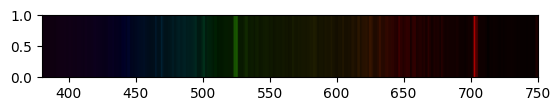

In [392]:
def forceAspect(ax,aspect=1):
    im = ax.get_images()
    extent =  im[0].get_extent()
    ax.set_aspect(abs((extent[1]-extent[0])/(extent[3]-extent[2]))/aspect)

fig, ax = plt.subplots()

L,M = np.meshgrid(wl, intensity)
extent = (np.min(wl), np.max(wl), 0, 1)
plt.imshow(L, clim=clim, extent=extent, cmap=spectralLinesMap, aspect="auto")

forceAspect(ax, 8)

try another thing

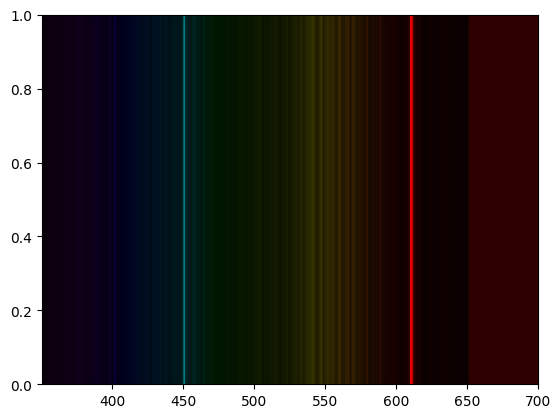

In [396]:
modulatedColorValues = []

for wl,mI in zip(wavelength, modulatedIntensityValues):
    wavelengthInRGB = wavelength_to_rgb(wl)[0:3]
    wavelengthInHSV = colorsys.rgb_to_hsv(*np.array(wavelengthInRGB))
    wavelengthInHSV2.append(wavelengthInHSV[2])
    wavelengthInHSV2timesMI.append(wavelengthInHSV[2]*mI)
    modulatedWavelength = np.append(wavelengthInHSV[0:2],wavelengthInHSV[2]*mI)#*mI)
    modulatedColorValues.append(colorsys.hsv_to_rgb(*modulatedWavelength))

blue = [i[2] if len(i) > 2 else '' for i in modulatedColorValues]

normalizeRange = plt.Normalize(min(wavelength), max(wavelength))
newspectralLinesList = list(zip(normalizeRange(wavelength), modulatedColorValues))
newspectralLinesMap = colors.LinearSegmentedColormap.from_list("newspectralLines", newspectralLinesList)

O,P = np.meshgrid(wavelength, intensity)
extent = (np.min(wavelength), np.max(wavelength), 0, 1)
plt.imshow(L, clim=(min(wavelength),max(wavelength)), extent=extent, cmap=newspectralLinesMap, aspect="auto")
